In [50]:
from google.colab import files
uploaded = files.upload()

Saving main-data-set-daily-4-fixed.xlsx to main-data-set-daily-4-fixed.xlsx


In [51]:
!pip -q install scikit-learn pandas numpy

In [52]:
import pandas as pd

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

df.to_csv("daily4_converted.csv", index=False)

print("Conversion complete")
df.head()

Conversion complete


,year,month,day,dayname,midday,evening
0,2021,1,1,Friday,6276,4206.0
1,2021,1,2,Saturday,8276,3380.0
2,2021,1,3,Sunday,1514,9468.0
3,2021,1,4,Monday,3421,3045.0
4,2021,1,5,Tuesday,2865,4898.0


In [53]:
import pandas as pd

CSV_NAME = "/content/daily4_converted.csv"

# Read a small text sample with latin1
with open(CSV_NAME, "r", encoding="latin1", errors="replace") as f:
    lines = [f.readline() for _ in range(50)]

# Guess delimiter by counting occurrences in the sample
candidates = [",", ";", "\t", "|"]
counts = {d: sum(line.count(d) for line in lines) for d in candidates}
sep_used = max(counts, key=counts.get)

print("Delimiter counts:", counts)
print("Chosen separator:", repr(sep_used))

# Now read using python engine (more tolerant)
df = pd.read_csv(
    CSV_NAME,
    encoding="latin1",
    sep=sep_used,
    engine="python",
    on_bad_lines="skip"
)

print("Loaded rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Delimiter counts: {',': 250, ';': 0, '\t': 0, '|': 0}
Chosen separator: ','
Loaded rows: 1879
Columns: ['year', 'month', 'day', 'dayname', 'midday', 'evening']


,year,month,day,dayname,midday,evening
0,2021,1,1,Friday,6276,4206.0
1,2021,1,2,Saturday,8276,3380.0
2,2021,1,3,Sunday,1514,9468.0
3,2021,1,4,Monday,3421,3045.0
4,2021,1,5,Tuesday,2865,4898.0


In [54]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['year', 'month', 'day', 'dayname', 'midday', 'evening'], dtype='object')


In [57]:
import pandas as pd
import numpy as np

CSV_NAME = "/content/daily4_converted.csv"

# ---- 1) Robust read: detect delimiter + tolerant encoding ----
with open(CSV_NAME, "r", encoding="latin1", errors="replace") as f:
    lines = [f.readline() for _ in range(50)]

candidates = [",", ";", "\t", "|"]
counts = {d: sum(line.count(d) for line in lines) for d in candidates}
sep_used = max(counts, key=counts.get)

print("Delimiter counts:", counts)
print("Chosen separator:", repr(sep_used))

df = pd.read_csv(
    CSV_NAME,
    encoding="latin1",
    sep=sep_used,
    engine="python",
    on_bad_lines="skip"
)

print("Loaded rows:", len(df))
print("Raw columns:", df.columns.tolist())

# ---- 2) Normalize column names ----
df.columns = df.columns.str.strip().str.lower()

# Optional: strip whitespace from ALL string cells
for c in df.columns:
    if df[c].dtype == "object":
        df[c] = df[c].astype(str).str.strip()

def z4(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return np.nan
    # handle numeric like 234.0 safely
    try:
        s = str(int(float(s)))
    except:
        pass
    return s.zfill(4)

# ---- 3) Build standardized "data" table (wide OR long) ----
has_midday = "midday" in df.columns
has_evening = "evening" in df.columns

# helper to safely coerce year/month/day
def coerce_int(series):
    return pd.to_numeric(series, errors="coerce").astype("Int64")

# ensure year/month/day exist
needed = {"year","month","day"}
missing_ymd = needed - set(df.columns)
if missing_ymd:
    raise ValueError(f"Missing required columns: {missing_ymd}. Found: {df.columns.tolist()}")

df["year"] = coerce_int(df["year"])
df["month"] = coerce_int(df["month"])
df["day"] = coerce_int(df["day"])

df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=df["day"]),
    errors="coerce"
)

if has_midday or has_evening:
    # WIDE format
    if has_midday:
        df["midday"] = df["midday"].apply(z4)
    if has_evening:
        df["evening"] = df["evening"].apply(z4)

    long_parts = []
    base = df[["date","year","month","day"]]

    if has_midday:
        long_parts.append(base.assign(draw_type="MIDDAY", number=df["midday"]))
    if has_evening:
        long_parts.append(base.assign(draw_type="EVENING", number=df["evening"]))

    data = pd.concat(long_parts, ignore_index=True)

else:
    # LONG format
    # detect number col
    if "number" not in df.columns:
        # try common alternatives
        for alt in ["num", "result", "winning_number", "draw_number"]:
            if alt in df.columns:
                df["number"] = df[alt]
                break
        if "number" not in df.columns:
            raise ValueError("Couldn't find a 'number' column (and no midday/evening columns).")

    df["number"] = df["number"].apply(z4)

    # detect draw_type col
    if "draw_type" not in df.columns:
        for alt in ["draw", "type", "drawtime", "draw_time", "game_time"]:
            if alt in df.columns:
                df["draw_type"] = df[alt]
                break
        if "draw_type" not in df.columns:
            raise ValueError("Couldn't find a 'draw_type' column in long format.")

    df["draw_type"] = df["draw_type"].astype(str).str.upper().str.strip()
    data = df[["date","year","month","day","draw_type","number"]].copy()

# ---- 4) Final cleaning ----
data = data.dropna(subset=["date","number"]).sort_values(["date","draw_type"]).reset_index(drop=True)

# Keep only valid 4-digit numbers
data = data[data["number"].astype(str).str.fullmatch(r"\d{4}", na=False)].reset_index(drop=True)

print("\nCleaned preview:")
display(data.head())

print("\nDraw type counts:")
print(data["draw_type"].value_counts(dropna=False))

Delimiter counts: {',': 250, ';': 0, '\t': 0, '|': 0}
Chosen separator: ','
Loaded rows: 1879
Raw columns: ['year', 'month', 'day', 'dayname', 'midday', 'evening']

Cleaned preview:


,date,year,month,day,draw_type,number
0,2021-01-01,2021,1,1,EVENING,4206
1,2021-01-01,2021,1,1,MIDDAY,6276
2,2021-01-02,2021,1,2,EVENING,3380
3,2021-01-02,2021,1,2,MIDDAY,8276
4,2021-01-03,2021,1,3,EVENING,9468



Draw type counts:
draw_type
MIDDAY     1879
EVENING    1878
Name: count, dtype: int64


In [58]:
import pandas as pd
import numpy as np

TARGET_DATE = pd.Timestamp("2026-02-22")

# --- 1) Build wide table: one row per date with midday/evening ---
mid = (data.loc[data["draw_type"].eq("MIDDAY"), ["date", "number"]]
          .rename(columns={"number": "midday"}))
eve = (data.loc[data["draw_type"].eq("EVENING"), ["date", "number"]]
          .rename(columns={"number": "evening"}))

wide = (mid.merge(eve, on="date", how="outer")
          .sort_values("date")
          .reset_index(drop=True))

# Keep as strings (preserve leading zeros)
for c in ["midday", "evening"]:
    if c in wide.columns:
        wide[c] = wide[c].astype("string")

# --- 2) Ensure TARGET_DATE exists (add empty row if missing) ---
if TARGET_DATE not in set(wide["date"]):
    wide = pd.concat(
        [wide, pd.DataFrame({"date": [TARGET_DATE], "midday": [pd.NA], "evening": [pd.NA]})],
        ignore_index=True
    ).sort_values("date").reset_index(drop=True)

# --- 3) Date features ---
wide["year"] = wide["date"].dt.year
wide["month"] = wide["date"].dt.month
wide["day"] = wide["date"].dt.day
wide["dow"] = wide["date"].dt.dayofweek
wide["weekofyear"] = wide["date"].dt.isocalendar().week.astype(int)

# --- 4) Lag features (previous day values) ---
wide["midday_prev"] = wide["midday"].shift(1)
wide["evening_prev"] = wide["evening"].shift(1)

# --- 5) Digit-split features (safe, no floats) ---
def split_digits_series(s: pd.Series, prefix: str) -> pd.DataFrame:
    # returns 4 columns: prefix_d0..d3 with Int64 (nullable)
    x = s.astype("string").str.zfill(4)
    d = x.str.extract(r"^(\d)(\d)(\d)(\d)$")
    d.columns = [f"{prefix}_d{i}" for i in range(4)]
    return d.apply(pd.to_numeric, errors="coerce").astype("Int64")

for c in ["midday", "midday_prev", "evening_prev"]:
    if c in wide.columns:
        d = split_digits_series(wide[c], c)
        wide = pd.concat([wide, d], axis=1)

# --- 6) Train rows: must have known target evening and required predictors ---
required = ["evening", "midday", "midday_prev", "evening_prev"]
train = wide.dropna(subset=required).copy()

# --- 7) Prediction row for TARGET_DATE (evening is unknown; midday/prev must exist) ---
pred_row = wide.loc[wide["date"].eq(TARGET_DATE)].copy()

display(pred_row)
print("Train rows:", len(train))

,date,midday,evening,year,month,day,dow,weekofyear,midday_prev,evening_prev,...,midday_d2,midday_d3,midday_prev_d0,midday_prev_d1,midday_prev_d2,midday_prev_d3,evening_prev_d0,evening_prev_d1,evening_prev_d2,evening_prev_d3
1878,2026-02-22,4785,<NA>,2026,2,22,6,8,7656,5774,...,8,5,7,6,5,6,5,7,7,4


Train rows: 1877


In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# ----------------------------
# 1) Build X / y safely
# ----------------------------
feature_cols = ["month","day","dow","weekofyear"] + \
               [f"midday_d{i}" for i in range(4)] + \
               [f"midday_prev_d{i}" for i in range(4)] + \
               [f"evening_prev_d{i}" for i in range(4)]

# Make sure all feature cols exist
missing = [c for c in feature_cols if c not in train.columns]
if missing:
    raise ValueError(f"Missing feature columns in train: {missing}")

# X train (fill NAs with -1 sentinel)
X = train[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(-1).astype(int)

# y digits (evening)
y_digits = train["evening"].astype("string").str.zfill(4).str.extract(r"^(\d)(\d)(\d)(\d)$")
y_digits = y_digits.apply(pd.to_numeric, errors="coerce").astype(int)

y = {i: y_digits[i].values for i in range(4)}

# X_pred
missing_pred = [c for c in feature_cols if c not in pred_row.columns]
if missing_pred:
    raise ValueError(f"Missing feature columns in pred_row: {missing_pred}")

X_pred = pred_row[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(-1).astype(int)

print("X:", X.shape, "X_pred:", X_pred.shape)

# Quick check: do we have enough info to predict?
if (X_pred.iloc[0] == -1).any():
    bad = X_pred.columns[(X_pred.iloc[0] == -1).values].tolist()
    print("\n⚠️ Prediction row has missing features (filled as -1):")
    print(bad)
    print("You need those values available (usually TARGET_DATE midday + previous day draws).")

# ----------------------------
# 2) Train 4 digit models
# ----------------------------
models = {}
pred_digits = []

for i in range(4):
    clf = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight=None
    )
    clf.fit(X, y[i])
    models[i] = clf
    pred_digits.append(int(clf.predict(X_pred)[0]))

pred_number = "".join(map(str, pred_digits))
print("\nPredicted EVENING (digits):", pred_digits)
print("Predicted EVENING number:", pred_number)

# ----------------------------
# 3) (Optional) show top-3 probs per digit
# ----------------------------
for i in range(4):
    proba = models[i].predict_proba(X_pred)[0]
    classes = models[i].classes_
    top3_idx = np.argsort(proba)[-3:][::-1]
    top3 = [(int(classes[j]), float(proba[j])) for j in top3_idx]
    print(f"Digit {i} top-3:", top3)

X: (1877, 16) X_pred: (1, 16)

Predicted EVENING (digits): [3, 9, 8, 0]
Predicted EVENING number: 3980
Digit 0 top-3: [(3, 0.142), (8, 0.134), (0, 0.12)]
Digit 1 top-3: [(9, 0.15), (0, 0.146), (7, 0.124)]
Digit 2 top-3: [(8, 0.22), (3, 0.144), (5, 0.12)]
Digit 3 top-3: [(0, 0.166), (7, 0.142), (5, 0.128)]


In [60]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import numpy as np
import copy

# ----- 1) Make NB-safe copies of X / X_pred -----
# CategoricalNB requires non-negative integers.
# We'll map missing to a dedicated category value.

X_nb = X.copy()
X_pred_nb = X_pred.copy()

# For digit-like columns: use 10 as "missing" category (valid digits are 0-9)
digit_cols = [c for c in feature_cols if c.endswith(("_d0","_d1","_d2","_d3"))]
for c in digit_cols:
    X_nb[c] = X_nb[c].replace(-1, 10)
    X_pred_nb[c] = X_pred_nb[c].replace(-1, 10)

# For calendar features: replace missing with mode (or 0)
cal_cols = ["month","day","dow","weekofyear"]
for c in cal_cols:
    if (X_nb[c] == -1).any():
        mode_val = int(X_nb.loc[X_nb[c] != -1, c].mode().iloc[0]) if (X_nb[c] != -1).any() else 0
        X_nb[c] = X_nb[c].replace(-1, mode_val)
    if (X_pred_nb[c] == -1).any():
        mode_val = int(X_nb[c].mode().iloc[0]) if len(X_nb[c].mode()) else 0
        X_pred_nb[c] = X_pred_nb[c].replace(-1, mode_val)

# ----- 2) Models + weights -----
models = {
    "NB": CategoricalNB(alpha=1.0),
    "RF": RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    "GB": GradientBoostingClassifier(random_state=42),
}

weights = {"NB": 0.25, "RF": 0.45, "GB": 0.30}

# ----- 3) Ensemble probs per digit position -----
ensemble_probs = [{str(d): 0.0 for d in range(10)} for _ in range(4)]

for name, base in models.items():
    w = weights[name]

    for pos in range(4):
        m = copy.deepcopy(base)

        # Use NB-safe matrices only for NB; others can use original X
        X_train_use = X_nb if name == "NB" else X
        X_pred_use  = X_pred_nb if name == "NB" else X_pred

        m.fit(X_train_use, y[pos])

        p = m.predict_proba(X_pred_use)[0]
        classes = m.classes_.astype(int)

        for cls, prob in zip(classes, p):
            cls = int(cls)
            if 0 <= cls <= 9:
                ensemble_probs[pos][str(cls)] += w * float(prob)

# ----- 4) Normalize with guard -----
for pos in range(4):
    s = sum(ensemble_probs[pos].values())
    if s <= 0:
        # fallback uniform if something went wrong
        for d in ensemble_probs[pos]:
            ensemble_probs[pos][d] = 0.1
    else:
        for d in ensemble_probs[pos]:
            ensemble_probs[pos][d] /= s

ensemble_probs

[{'0': 0.22291622233395192,
  '1': 0.09061285676045622,
  '2': 0.064038793550873,
  '3': 0.12896532168843763,
  '4': 0.10549076353288993,
  '5': 0.0708582983686425,
  '6': 0.044996725815511236,
  '7': 0.06362969456118758,
  '8': 0.1447024233559655,
  '9': 0.0637889000320845},
 {'0': 0.10494703062771742,
  '1': 0.08165325773008003,
  '2': 0.0552014046534258,
  '3': 0.14660358321887296,
  '4': 0.10534265452435944,
  '5': 0.07636368311904027,
  '6': 0.04029540961005365,
  '7': 0.14327954097609008,
  '8': 0.09885064366610272,
  '9': 0.14746279187425765},
 {'0': 0.05590142635947909,
  '1': 0.08182026937759243,
  '2': 0.11199118000181588,
  '3': 0.10957642643059287,
  '4': 0.036394010094084835,
  '5': 0.2072899348878776,
  '6': 0.045654367517832035,
  '7': 0.1227923594140255,
  '8': 0.14153023048894814,
  '9': 0.08704979542775154},
 {'0': 0.11884584392377177,
  '1': 0.1043771224613271,
  '2': 0.10632044559987858,
  '3': 0.11181440983204517,
  '4': 0.08774562141332043,
  '5': 0.10393666937364

In [61]:
from collections import Counter
import pandas as pd
import numpy as np

alpha = 1.0
digits = "0123456789"

# ---- 1) Build transition counts P(e_digit | m_digit) per position ----
trans = [Counter() for _ in range(4)]
base  = [Counter() for _ in range(4)]

for _, r in train.iterrows():
    m = r.get("midday", None)
    e = r.get("evening", None)

    if pd.isna(m) or pd.isna(e):
        continue

    m = str(m).zfill(4)
    e = str(e).zfill(4)

    if (len(m) != 4) or (len(e) != 4) or (not m.isdigit()) or (not e.isdigit()):
        continue

    for pos in range(4):
        trans[pos][(m[pos], e[pos])] += 1
        base[pos][m[pos]] += 1

# ---- 2) Convert to smoothed transition probabilities ----
trans_prob = []
for pos in range(4):
    dct = {}
    for md in digits:
        denom = base[pos][md] + 10 * alpha
        for ed in digits:
            dct[(md, ed)] = (trans[pos][(md, ed)] + alpha) / denom
    trans_prob.append(dct)

# ---- 3) Apply to TARGET_DATE midday digits ----
mid_today = pred_row["midday"].iloc[0] if len(pred_row) else None
if pd.isna(mid_today):
    raise ValueError("pred_row['midday'] is missing for TARGET_DATE. Add the midday result first.")

mid_today = str(mid_today).zfill(4)
if not mid_today.isdigit() or len(mid_today) != 4:
    raise ValueError(f"Invalid midday value for TARGET_DATE: {mid_today}")

extra = [{d: 0.0 for d in digits} for _ in range(4)]
for pos in range(4):
    for ed in digits:
        extra[pos][ed] = trans_prob[pos][(mid_today[pos], ed)]

# ---- 4) Blend with your ensemble_probs ----
blend = 0.20  # 20% transition Bayes, 80% model ensemble
final_probs = []
for pos in range(4):
    fp = {}
    for d in digits:
        fp[d] = (1 - blend) * float(ensemble_probs[pos][d]) + blend * float(extra[pos][d])
    s = sum(fp.values())
    if s <= 0:
        fp = {d: 0.1 for d in digits}
        s = 1.0
    for d in fp:
        fp[d] /= s
    final_probs.append(fp)

final_probs

[{'0': 0.19976154929573298,
  '1': 0.08881681602060988,
  '2': 0.06959838177947392,
  '3': 0.11949878796299501,
  '4': 0.10582118225488338,
  '5': 0.07811521012348543,
  '6': 0.056405543917715115,
  '7': 0.06825069442446027,
  '8': 0.14025173460313978,
  '9': 0.07348009961750433},
 {'0': 0.10868880729787286,
  '1': 0.07930110080771995,
  '2': 0.06459123124962236,
  '3': 0.1452398558224102,
  '4': 0.10255369351196067,
  '5': 0.07937051638770534,
  '6': 0.052666435214924645,
  '7': 0.13075266503893657,
  '8': 0.09843535364255959,
  '9': 0.13840034102628784},
 {'0': 0.06034614108758327,
  '1': 0.08524788216874062,
  '2': 0.1145929440014527,
  '3': 0.10745280781114097,
  '4': 0.05099020807526787,
  '5': 0.1877069479103021,
  '6': 0.04798182734759896,
  '7': 0.11802555419788707,
  '8': 0.13718251772449186,
  '9': 0.09047316967553456},
 {'0': 0.1109496910120333,
  '1': 0.09937471384207756,
  '2': 0.10410397552752192,
  '3': 0.10532454373865202,
  '4': 0.08924411617827539,
  '5': 0.1032551556

In [62]:
pred = []
for pos in range(4):
    top = sorted(final_probs[pos].items(), key=lambda kv: kv[1], reverse=True)
    print(f"pos {pos} top-3:", top[:3])
    pred.append(top[0][0])

print("FINAL predicted evening:", "".join(pred))

pos 0 top-3: [('0', 0.19976154929573298), ('8', 0.14025173460313978), ('3', 0.11949878796299501)]
pos 1 top-3: [('3', 0.1452398558224102), ('9', 0.13840034102628784), ('7', 0.13075266503893657)]
pos 2 top-3: [('5', 0.1877069479103021), ('8', 0.13718251772449186), ('7', 0.11802555419788707)]
pos 3 top-3: [('7', 0.15473256240296238), ('0', 0.1109496910120333), ('3', 0.10532454373865202)]
FINAL predicted evening: 0357


In [63]:
import itertools
from functools import lru_cache

# Straight probability
def straight_prob(num):
    return (
        final_probs[0][num[0]] *
        final_probs[1][num[1]] *
        final_probs[2][num[2]] *
        final_probs[3][num[3]]
    )

# Cache permutations
@lru_cache(None)
def unique_perms(num):
    return set("".join(p) for p in itertools.permutations(num, 4))

# Box probability
def box_prob(num):
    perms = unique_perms(num)
    return sum(straight_prob(p) for p in perms), len(perms)

# Score numbers
scored = []

for n in range(10000):
    num = f"{n:04d}"

    sp = straight_prob(num)
    bp, k = box_prob(num)

    scored.append((sp, bp, k, num))

# Sort by straight probability
scored.sort(key=lambda x: x[0], reverse=True)

top30 = scored[:30]

top30[:5]

[(0.0008426743457659352, 0.0049182632991193855, 24, '0357'),
 (0.0008029918245768061, 0.004137032487473016, 24, '0957'),
 (0.0007586203927630001, 0.002419486519510337, 12, '0757'),
 (0.0006306069987690167, 0.002453410225274084, 12, '0057'),
 (0.0006158546056017641, 0.004514564354219587, 24, '0387')]

Top 10 by STRAIGHT:


,straight_p,box_p,perm_count,number
0,0.000843,0.004918,24,0357
1,0.000803,0.004137,24,0957
2,0.000759,0.002419,12,0757
3,0.000631,0.002453,12,0057
4,0.000616,0.004515,24,0387
5,0.000604,0.002391,12,0350
6,0.000595,0.003610,24,0457
7,0.000592,0.004167,24,8357
8,0.000587,0.003826,24,0987
9,0.000576,0.002054,12,0950


Top 10 by BOX:


,straight_p,box_p,perm_count,number
0,0.000843,0.004918,24,0357
1,0.000516,0.004918,24,0753
2,0.000616,0.004515,24,0387
3,0.000571,0.004326,24,0857
4,0.000592,0.004167,24,8357
5,0.000803,0.004137,24,0957
6,0.000547,0.004099,24,0953
7,0.000521,0.004099,24,0359
8,0.000587,0.003826,24,0987
9,0.000514,0.003767,24,0327



Wheel digits per position (top3 each): [['0', '8', '3'], ['3', '9', '7'], ['5', '8', '7'], ['7', '0', '3']]
Wheel count: 81
Wheel sample (first 30): ['0357', '0350', '0353', '0387', '0380', '0383', '0377', '0370', '0373', '0957', '0950', '0953', '0987', '0980', '0983', '0977', '0970', '0973', '0757', '0750', '0753', '0787', '0780', '0783', '0777', '0770', '0773', '8357', '8350', '8353']

2-Way pairs (from top BOX picks):
0357 <-> 0375
0357 <-> 7350
0735 <-> 0753
0753 <-> 3750
0378 <-> 0387
0387 <-> 7380
0857 <-> 0875
0857 <-> 7850
8357 <-> 8375
7358 <-> 8357
0957 <-> 0975
0957 <-> 7950
0935 <-> 0953
0953 <-> 3950
0359 <-> 0395
0359 <-> 9350
0978 <-> 0987
0987 <-> 7980
0327 <-> 0372
0327 <-> 7320
0457 <-> 0475
0457 <-> 7450
0315 <-> 0351
0351 <-> 1350
0325 <-> 0352
0352 <-> 2350
0725 <-> 0752
0752 <-> 2750
8957 <-> 8975
7958 <-> 8957

ON/OFF digit suggestion (per position):
pos0 ON=['0', '8', '3', '4']   OFF=['9', '2', '7', '6']
pos1 ON=['3', '9', '7', '0']   OFF=['5', '1', '2', '6']
p

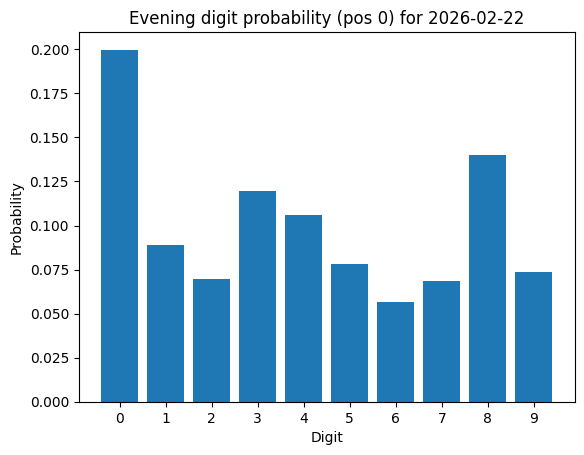

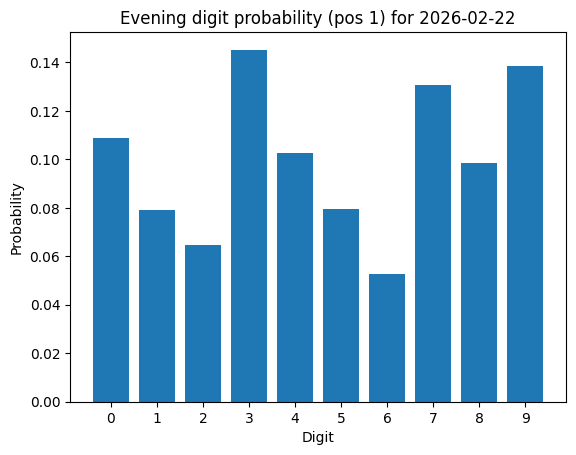

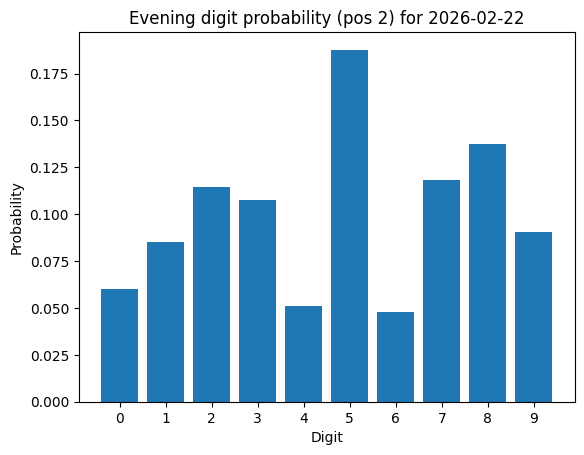

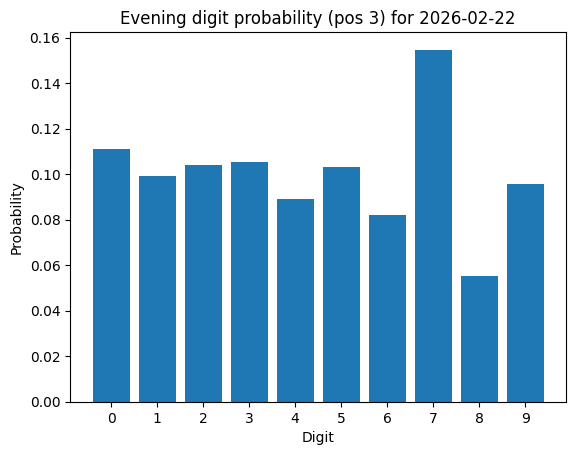

In [64]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1) top_df: show top30 sorted by straight and by box ----
top_df = pd.DataFrame(top30, columns=["straight_p","box_p","perm_count","number"])

top_df_straight = top_df.sort_values("straight_p", ascending=False).reset_index(drop=True)
top_df_box      = top_df.sort_values("box_p", ascending=False).reset_index(drop=True)

print("Top 10 by STRAIGHT:")
display(top_df_straight.head(10))

print("Top 10 by BOX:")
display(top_df_box.head(10))

# ---- 2) Wheel suggestion ----
def top_digits(pos, k=3):
    ranked = sorted(final_probs[pos].items(), key=lambda x: x[1], reverse=True)[:k]
    return [d for d,_ in ranked]  # digits as strings

wheel_sets = [top_digits(i, k=3) for i in range(4)]
wheel_numbers = ["".join(p) for p in itertools.product(*wheel_sets)]

def human_pattern(n):
    runs = {
        "0123","1234","2345","3456","4567","5678","6789",
        "9876","8765","7654","6543","5432","4321","3210"
    }
    return (len(set(n)) == 1) or (n in runs)

wheel_numbers = [n for n in wheel_numbers if not human_pattern(n)]

print("\nWheel digits per position (top3 each):", wheel_sets)
print("Wheel count:", len(wheel_numbers))
print("Wheel sample (first 30):", wheel_numbers[:30])

# ---- 3) 2-way pairs (improved) ----
# Your original: swap last two digits
def swap_last_two(n):
    return n[:2] + n[3] + n[2]

# Add common swap: swap first and last
def swap_first_last(n):
    return n[3] + n[1:3] + n[0]

# Build from top BOX picks (usually better for wheels)
two_way = []
seen = set()
for n in top_df_box["number"].head(30):
    for swapped in [swap_last_two(n), swap_first_last(n)]:
        if swapped != n:
            pair = tuple(sorted([n, swapped]))
            if pair not in seen:
                seen.add(pair)
                two_way.append(pair)

print("\n2-Way pairs (from top BOX picks):")
for a, b in two_way[:30]:
    print(a, "<->", b)

# ---- 4) ON/OFF digits per position ----
on_off = []
for pos in range(4):
    ranked = sorted(final_probs[pos].items(), key=lambda x: x[1], reverse=True)
    ON = [d for d,_ in ranked[:4]]
    OFF = [d for d,_ in ranked[-4:]]
    on_off.append((pos, ON, OFF))

print("\nON/OFF digit suggestion (per position):")
for pos, ON, OFF in on_off:
    print(f"pos{pos} ON={ON}   OFF={OFF}")

# ---- 5) Plot per-position probability bars ----
for pos in range(4):
    xs = [str(d) for d in range(10)]
    ys = [final_probs[pos].get(str(d), 0.0) for d in range(10)]
    plt.figure()
    plt.bar(xs, ys)
    plt.title(f"Evening digit probability (pos {pos}) for {TARGET_DATE.date()}")
    plt.xlabel("Digit")
    plt.ylabel("Probability")
    plt.show()